# Visualize Saved Logit Lens Training Results

This notebook loads the newest saved tuned lens from `results/`, reads the matching training CSV when available, loads Pile-10k, and compares tuned-lens and logit-lens predictions.

In [55]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import transformer_lens as tl
from datasets import load_dataset
from lens import logit_lens, tuned_lens
from transformer_lens import HookedTransformer

device = "cuda:1" if torch.cuda.is_available() else "cpu"
results_dir = Path("results")

def latest_lens_path(results_dir=results_dir):
    candidates = [
        path for path in results_dir.glob("*.pt")
        if not path.name.startswith("distance_to_final_")
    ]
    if not candidates:
        raise FileNotFoundError("No saved tuned lens found in results/.")
    return max(candidates, key=lambda path: path.stat().st_mtime)

def matching_training_csv(lens_path):
    exact_path = lens_path.with_name(f"{lens_path.stem}_training.csv")
    if exact_path.exists():
        return exact_path
    candidates = list(results_dir.glob("*_training.csv"))
    return max(candidates, key=lambda path: path.stat().st_mtime) if candidates else None

lens_path = latest_lens_path()
lens_checkpoint = torch.load(lens_path, map_location="cpu")
training_csv_path = matching_training_csv(lens_path)
training_df = pd.read_csv(training_csv_path) if training_csv_path is not None else None

def metadata_value(key, default=None):
    if training_df is not None and key in training_df.columns and len(training_df) > 0:
        value = training_df.iloc[0][key]
        if not pd.isna(value):
            return value
    return lens_checkpoint.get(key, default)

print(f"Using device: {device}")
print(f"Loaded tuned lens: {lens_path}")
if training_csv_path is not None:
    print(f"Loaded training CSV: {training_csv_path}")
print(f"Probe input normalization: {metadata_value('probe_input_normalization', 'raw_resid_post')}")

Using device: cuda:1
Loaded tuned lens: results/probe_heads_20260509_005342.pt
Loaded training CSV: results/probe_heads_20260509_005342_training.csv
Probe input normalization: raw_resid_post


In [56]:
model_name = metadata_value("model_name", "pythia-14m")
model: HookedTransformer = tl.HookedTransformer.from_pretrained(model_name, device=device)
model.eval()
for parameter in model.parameters():
    parameter.requires_grad_(False)

if "model_state_dict" in lens_checkpoint:
    model.load_state_dict(lens_checkpoint["model_state_dict"], strict=False)
    print("Loaded saved base-model state from checkpoint.")

tlens = tuned_lens(model, device).load_lens(lens_path)
llens = logit_lens()
unembedding_matrices = tlens.unembedding_matrices
num_model_blocks = len(unembedding_matrices)

print(f"Loaded model: {model_name}")
print(f"Number of block heads: {num_model_blocks}")
print(f"d_model={model.cfg.d_model}, d_vocab={model.cfg.d_vocab}")

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 17435.16it/s]


Loaded pretrained model pythia-14m into HookedTransformer
Loaded model: pythia-14m
Number of block heads: 6
d_model=128, d_vocab=50304


In [57]:
ds = load_dataset("NeelNanda/pile-10k")

context_window = int(metadata_value("context_window", 10))
num_text_samples = min(int(metadata_value("num_text_samples", 1000)), len(ds["train"]))
rng = np.random.default_rng(seed=0)
randoms = rng.choice(len(ds["train"]), size=num_text_samples, replace=False)

chunks = []
for dataset_idx in randoms:
    text = ds["train"][int(dataset_idx)]["text"]
    encoded = model.tokenizer.encode(text)
    if len(encoded) < context_window + 1:
        continue

    encoded = torch.tensor(encoded, dtype=torch.long)
    chunks.append(encoded.unfold(0, context_window + 1, 1))

if not chunks:
    raise ValueError("No token windows were created. Try lowering context_window or sampling more texts.")

tokens = torch.cat(chunks, dim=0).contiguous()


## Shown here is the crossentropy loss by training step for the thing...

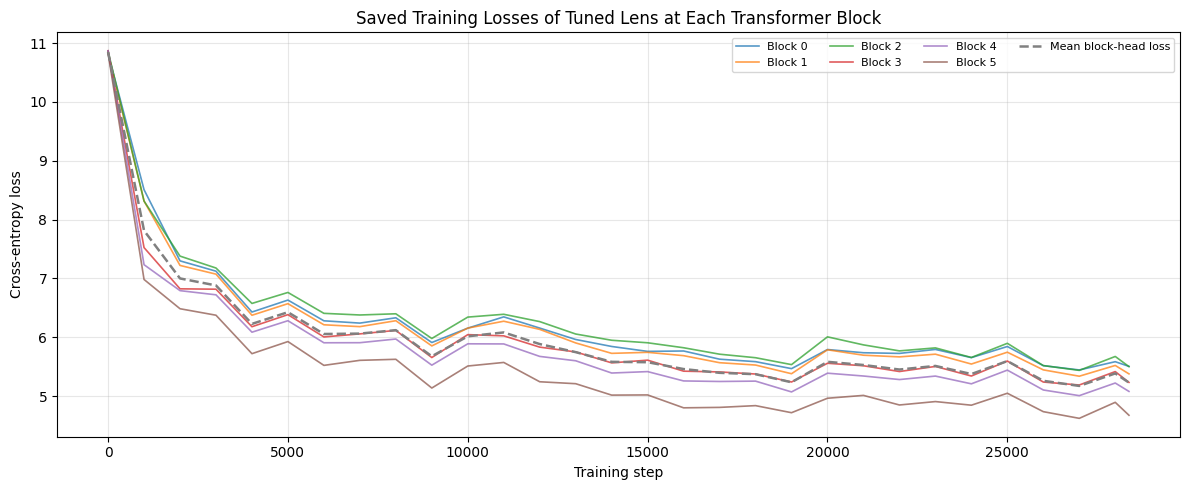

Saved training steps: 28382
Last mean block loss: 5.2301
Last block loss sum: 31.3805
Last block losses:
  block 00: 5.5066
  block 01: 5.3792
  block 02: 5.5029
  block 03: 5.2346
  block 04: 5.0810
  block 05: 4.6762


In [58]:
plot_every = 1000

if training_df is None and "training_history" in lens_checkpoint:
    rows = []
    for entry in lens_checkpoint["training_history"]:
        row = {key: value for key, value in entry.items() if key != "block_losses"}
        for layer, loss in enumerate(entry.get("block_losses", [])):
            row[f"block_{layer}_loss"] = loss
        rows.append(row)
    training_df = pd.DataFrame(rows)

if training_df is None or training_df.empty:
    print("No training CSV or embedded training history was found.")
else:
    block_loss_columns = sorted(
        [col for col in training_df.columns if col.startswith("block_") and col.endswith("_loss")],
        key=lambda col: int(col.split("_")[1]),
    )
    xs = np.arange(len(training_df))
    plot_idx = np.unique(np.r_[np.arange(0, len(xs), plot_every), len(xs) - 1])
    block_losses = training_df[block_loss_columns].to_numpy(dtype=float)
    block_loss_means = np.nanmean(block_losses, axis=1)
    block_loss_sums = np.nansum(block_losses, axis=1)
    total_losses = training_df["total_loss"].to_numpy(dtype=float) if "total_loss" in training_df else np.full(len(training_df), np.nan)

    plt.figure(figsize=(12, 5))
    for layer, losses in enumerate(block_losses.T):
        plt.plot(xs[plot_idx], losses[plot_idx], alpha=0.75, linewidth=1.2, label=f"Block {layer}")
    # plt.plot(xs[plot_idx], final_losses[plot_idx], color="black", label="Final head loss", linewidth=2.2)
    plt.plot(xs[plot_idx], block_loss_means[plot_idx], color="gray", linestyle="--", label="Mean block-head loss", linewidth=1.8)
    if not np.isnan(total_losses).all():
        plt.plot(xs[plot_idx], total_losses[plot_idx], label="Total loss", alpha=0.6)
    plt.title("Saved Training Losses of Tuned Lens at Each Transformer Block")
    plt.xlabel("Training step")
    plt.ylabel("Cross-entropy loss")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=4, fontsize=8)
    plt.tight_layout()
    plt.show()

    print(f"Saved training steps: {len(training_df)}")
    print(f"Last mean block loss: {block_loss_means[-1]:.4f}")
    print(f"Last block loss sum: {block_loss_sums[-1]:.4f}")
    print("Last block losses:")
    for layer, loss_value in enumerate(block_losses[-1]):
        print(f"  block {layer:02d}: {loss_value:.4f}")

## Shown below is a plot of the cross-entropy between the predicted values from each lens after each transformer block, and the true next token.

### As can be seen, the tuned lens gives a better cross-entropy loss than the model's final unembed layer.

torch.Size([2000, 10])


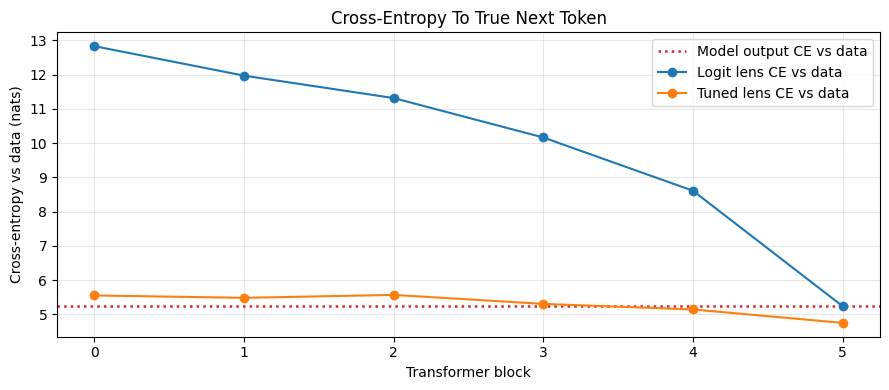

Model output cross-entropy vs data: 5.2382 nats
Final-layer logit-lens cross-entropy vs data: 5.2382 nats
Final-layer tuned-lens cross-entropy vs data: 4.7505 nats


In [59]:
ce_sample_size = min(2000, tokens.shape[0])
sample_idx = torch.tensor(
    np.random.default_rng(seed=1).choice(tokens.shape[0], size=ce_sample_size, replace=False),
    dtype=torch.long,
)
sample_inputs = tokens[sample_idx, :-1].to(device)
sample_targets = tokens[sample_idx, 1:].to(device)
print(sample_inputs.shape)

probe_input_normalization = metadata_value("probe_input_normalization", "raw_resid_post")
apply_ln_to_probe_inputs = probe_input_normalization == "ln_final_resid_post"

with torch.no_grad():
    _, sample_cache = model.run_with_cache(
        sample_inputs,
        names_filter=lambda name: name.endswith("hook_resid_post"),
        return_type=None,
    )
    final_resid = sample_cache["resid_post", num_model_blocks - 1]
    final_logits = model.unembed(model.ln_final(final_resid))

    def ce_by_pos(logits):
        return F.cross_entropy(
            logits.reshape(-1, logits.shape[-1]),
            sample_targets.reshape(-1),
            reduction="none",
        ).reshape_as(sample_targets).cpu()

    final_data_ce_by_pos = ce_by_pos(final_logits)

    def tuned_lens_logits(layer):
        block_resid = sample_cache["resid_post", layer]
        if apply_ln_to_probe_inputs:
            block_resid = model.ln_final(block_resid)
        return tlens.unembedding_matrices[layer](block_resid)

    logit_lens_ce_by_pos = torch.stack([
        ce_by_pos(model.unembed(model.ln_final(sample_cache["resid_post", layer])))
        for layer in range(num_model_blocks)
    ])
    tuned_lens_ce_by_pos = torch.stack([
        ce_by_pos(tuned_lens_logits(layer))
        for layer in range(num_model_blocks)
    ])

logit_lens_ce = logit_lens_ce_by_pos.mean(dim=(1, 2)).numpy()
tuned_lens_ce = tuned_lens_ce_by_pos.mean(dim=(1, 2)).numpy()
final_data_ce = final_data_ce_by_pos.mean().item()
layers = np.arange(num_model_blocks)

fig, ax = plt.subplots(figsize=(9, 4))
ax.axhline(final_data_ce, color="tab:red", linestyle=":", linewidth=1.8, label="Model output CE vs data")
ax.plot(layers, logit_lens_ce, marker="o", label="Logit lens CE vs data")
ax.plot(layers, tuned_lens_ce, marker="o", label="Tuned lens CE vs data")
ax.set_title("Cross-Entropy To True Next Token")
ax.set_xlabel("Transformer block")
ax.set_ylabel("Cross-entropy vs data (nats)")
ax.grid(True, alpha=0.3)
ax.legend()
# plt.xscale("log")
plt.tight_layout()
plt.show()

print(f"Model output cross-entropy vs data: {final_data_ce:.4f} nats")
print(f"Final-layer logit-lens cross-entropy vs data: {logit_lens_ce[-1]:.4f} nats")
print(f"Final-layer tuned-lens cross-entropy vs data: {tuned_lens_ce[-1]:.4f} nats")

## Final Thoughts

Tuned lens seems to give a better understanding of where the model is at in the thinking process than logit-lens. However, we aren't given much information. Towards the end of the blocks, we start to see some resemblences of what will be in the output, but a major appeal to using an LLM in the first place is the fact that the "thinking" is complex. The status of the llm in the middle of its transformer blocks cannot be trivialized to words, especially if we expect complex "thinking" to occur.

So, in summary, I would say tuned_lens are interesting, and might provide *some* insight on what happens in each transformer block, but we cannot use them for any sort of rigorous analysis on the llm's capabilities.

Don't get me wrong, I acknowledge that this was a great step in mech-interp, and the results are interesting! But I believe better methods exist to evaluate llm reasoning than this.

# See below to test outhow each 

## Functions that print the decoded logit lens and tuned lens outputs

In [60]:
def tuned_lens_outputs(text, tlens, model):
    '''
    Print outputs of tuned lens at each transformer block
    '''
    with torch.no_grad():
        tokens = model.to_tokens(text).to(device)
        outputs = tlens.return_unembeddings(model, tokens)
        print(f"Tuned lens outputs for input: '{text}'")
        for layer, output in enumerate(outputs):
            selected_output = output.argmax(dim=-1).cpu().numpy()
            output_text = model.tokenizer.decode(selected_output[0])
            print(f"Block head {layer}: {output_text}")

        model_logits = model(tokens)
        model_output = model_logits.argmax(dim=-1).cpu().numpy()
        model_text = model.tokenizer.decode(model_output[0])
        print(f"Model output: {model_text}")


In [61]:
def logit_lens_outputs(text, model):
    '''
    Print logit lens outputs at each transformer block
    '''
    with torch.no_grad():
        tokens = model.to_tokens(text).to(device)
        _, cache = model.run_with_cache(tokens)
        print(f"Logit lens outputs for input: '{text}'")
        for layer in range(model.cfg.n_layers):
            block_output = cache["resid_post", layer]
            block_logits = model.unembed(model.ln_final(block_output))
            selected_output = block_logits.argmax(dim=-1).cpu().numpy()
            output_text = model.tokenizer.decode(selected_output[0])
            print(f"Block head {layer}: {output_text}")


In [62]:
prompt = "The quick brown fox jumps over the lazy dog"

In [63]:
logit_lens_outputs(prompt, model)

Logit lens outputs for input: 'The quick brown fox jumps over the lazy dog'
Block head 0: 
ly
,.;@",,
Block head 1: 
,ness,. the}",,
Block head 2:  "nessizations, ( the "ness,
Block head 3:  "if-- in the "-,
Block head 4:  "nessifiedesively the " natureifier
Block head 5: 
-ish, to the time,.


In [64]:
tuned_lens_outputs(prompt, tlens, model)

Tuned lens outputs for input: 'The quick brown fox jumps over the lazy dog'
Block head 0:  first to... the same to.
Block head 1:  first to-. to the same-.
Block head 2: 
--,. the
,,
Block head 3: 
--. to the
-,
Block head 4: 
ly,. to the
 and.
Block head 5: 
--, out the same and.
Model output: 
-ish, to the time,.
